# Multi-band HST-like strong-lens images

The `caustics` package supplies the differentiable macro lens and surface-
brightness profiles. `microcaustics` supplies the high-level renderer and
validated result container.  The source contains a resolved Sérsic host and
compact nucleus, while a separate Sérsic component represents lens-galaxy
light.  Each band is supersampled, convolved with its own HST-like PSF, and
given a reproducible high-S/N Poisson-plus-read-noise realization.

The panels show the individual bands—not an arbitrary RGB composite.  A
single adopted photometric zero point converts normalized pixel flux to mock
surface brightness in mag arcsec$^{-2}$, making the displayed units explicit.


In [1]:
import torch
import caustics
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
cosmology = caustics.FlatLambdaCDM()
lens = caustics.SIE(
    cosmology=cosmology,
    z_l=0.5,
    z_s=1.5,
    x0=0.0,
    y0=0.0,
    q=0.72,
    phi=0.4,
    Rein=0.9,
)
source_center = (0.04, -0.02)
solutions = mc.solve_caustics_macroimages(
    lens,
    *source_center,
    initial_grid_size=120,
    field_of_view_arcsec=2.0,
)
for solution in solutions:
    print(
        solution.name,
        f"(x,y)=({solution.x_arcsec:.3f},{solution.y_arcsec:.3f}) arcsec",
        f"delay={solution.arrival_time_delay_days:.2f} d",
        f"macro mu={solution.macro_magnification:.2f}",
    )


A (x,y)=(0.500,-0.840) arcsec delay=0.00 d macro mu=4.65
B (x,y)=(-0.178,0.893) arcsec delay=6.10 d macro mu=6.54
C (x,y)=(0.726,0.480) arcsec delay=9.58 d macro mu=-4.99
D (x,y)=(-0.785,-0.209) arcsec delay=14.23 d macro mu=-3.40


In [2]:
bands = ("g", "r", "i")
wavelengths = (4770.0, 6231.0, 7625.0)
grid = mc.ImagePlaneGrid((192, 192), (3.2, 3.2))
renderer = mc.CausticsMacroImageRenderer(
    lens, grid, band_names=bands, wavelengths_angstrom=wavelengths,
    upsample_factor=2, quadrature_level=2, psf_mode="conv2d",
    units="normalized pixel flux",
)

def source_model(host_intensity, nucleus_intensity, name):
    host = caustics.Sersic(
        x0=source_center[0], y0=source_center[1], q=0.68, phi=0.75,
        n=1.3, Re=0.16, Ie=host_intensity, name=f"{name}_host",
    )
    nucleus = caustics.StarSource(
        x0=source_center[0], y0=source_center[1], theta_s=0.003,
        Ie=nucleus_intensity, gamma=0.5, name=f"{name}_nucleus",
    )
    return caustics.LightStack((host, nucleus), name=f"{name}_source")

sources = tuple(
    source_model(host, nucleus, band)
    for host, nucleus, band in zip(
        (0.65, 0.80, 0.95), (900.0, 760.0, 620.0), bands, strict=True
    )
)
lens_light = tuple(
    caustics.Sersic(
        x0=0.0, y0=0.0, q=0.78, phi=0.4, n=4.0, Re=0.55,
        Ie=value, name=f"{band}_lens_light",
    )
    for value, band in zip((0.16, 0.24, 0.34), bands, strict=True)
)

psfs = tuple(
    mc.gaussian_psf_kernel(
        fwhm,
        grid.pixel_scale_arcsec[0],
        size=17,
        oversample_factor=renderer.upsample_factor,
    )
    for fwhm in (0.085, 0.080, 0.078)
)


In [3]:
observation_model = mc.PeakScaledPoissonReadNoise(
    peak_electrons=5000.0,
    read_noise_fraction=1.0 / 250.0,
)

image = renderer.render(
    0.0,
    sources=sources,
    lens_light=lens_light,
    psf=psfs,
    observation_model=observation_model,
    generator=torch.Generator().manual_seed(7),
    retain_components=True,
)


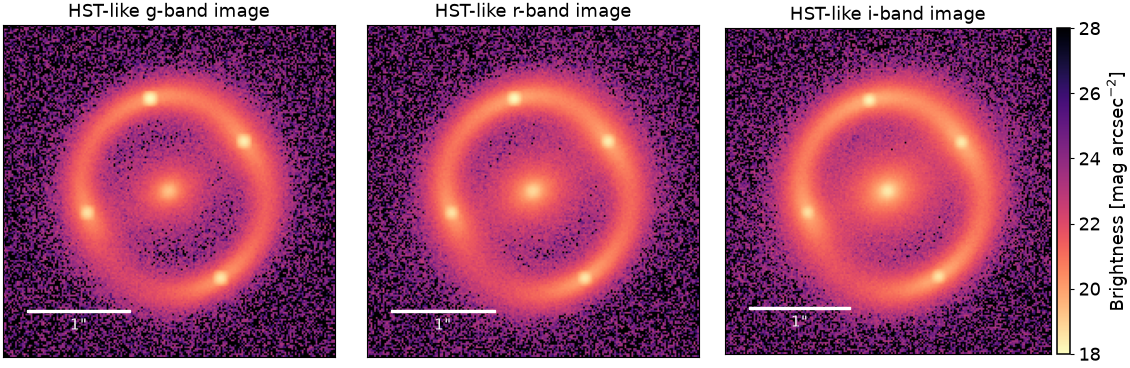

In [4]:
values = image.numpy()
pixel_area_arcsec2 = grid.pixel_scale_arcsec[0] * grid.pixel_scale_arcsec[1]
surface_flux = values / pixel_area_arcsec2
positive = surface_flux[surface_flux > 0]
# This zero point places the brightest pixel near 18 mag arcsec^-2. It is an
# explicit mock calibration, not a claim that normalized renderer units are
# intrinsically AB-calibrated.
zero_point = 18.0 + 2.5 * torch.log10(torch.as_tensor(float(positive.max()))).item()
surface_flux_tensor = torch.as_tensor(surface_flux)
surface_brightness = torch.full_like(surface_flux_tensor, float("nan"))
positive_mask = surface_flux_tensor > 0
surface_brightness[positive_mask] = (
    -2.5 * torch.log10(surface_flux_tensor[positive_mask]) + zero_point
)
vmin, vmax = 18.0, 28.0
cmap = plt.colormaps["magma_r"].copy()
cmap.set_bad("black")

figure, axes = plt.subplots(1, 3, figsize=(11.7, 3.8))
last_artist = None
for index, (ax, band) in enumerate(zip(axes, bands, strict=True)):
    last_artist = ax.imshow(
        surface_brightness[:, :, index].numpy(),
        origin="lower",
        extent=grid.bounds_arcsec,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )
    ax.set_title(f"HST-like {band}-band image")
    mcp.add_scale_bar(
        ax, 1.0, label=r'1"', color="white", font_size=11,
        borderpad=1.3, pad=0.25,
    )
    mcp.hide_image_axes(ax)
mcp.panel_colorbar(
    figure,
    axes[-1],
    last_artist,
    label=r"Brightness [mag arcsec$^{-2}$]",
)
figure.tight_layout()
